## Core Libraries and Imports

In [35]:
# =========================
# 1. CORE LIBRARIES
# =========================
import os
import random
import numpy as np
import pandas as pd
import cv2

# =========================
# 2. DATA PROCESSING
# =========================
from tqdm import tqdm
from collections import Counter
from pathlib import Path

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# =========================
# 3. IMAGE PROCESSING
# =========================
from PIL import Image, ImageEnhance
from skimage.feature import hog

# =========================
# 4. MACHINE LEARNING MODELS
# =========================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# =========================
# 5. METRICS
# =========================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# 6. DEEP LEARNING (TensorFlow / Keras)
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization
)

from tensorflow.keras.optimizers import *
from tensorflow.keras.losses import *
from tensorflow.keras.metrics import *
from tensorflow.keras.applications import *
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import plot_model

# =========================
# 7. VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('dark_background')

This cell imports all necessary Python libraries for data manipulation, image processing, machine learning, deep learning (TensorFlow/Keras), and visualization. It categorizes imports for better organization.

## Define Dataset Paths and Image Size

In [36]:
# Kaggle dataset paths
TRAIN_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_PATH  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"

IMG_SIZE = 224

This cell defines the file paths for the training and testing datasets and sets the target image size for processing.

## Load Training Data

In [37]:
train_images = []
train_labels = []

for folder in os.listdir(TRAIN_PATH):
    folder_path = os.path.join(TRAIN_PATH, folder)

    for file in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        train_images.append(img)
        train_labels.append(folder)

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print("Train Images:", train_images.shape)

100%|██████████| 1400/1400 [00:03<00:00, 426.85it/s]


Train Images: (5600, 224, 224)


This code iterates through the training dataset folders, reads each image, resizes it to `IMG_SIZE`, converts it to grayscale, and stores the processed images and their corresponding labels in lists. Finally, it converts these lists to NumPy arrays and prints the shape of the training images.

## Load Testing Data

In [38]:
test_images = []
test_labels = []

for folder in os.listdir(TEST_PATH):
    folder_path = os.path.join(TEST_PATH, folder)

    for file in tqdm(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        test_images.append(img)
        test_labels.append(folder)

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print("Test Images:", test_images.shape)

100%|██████████| 400/400 [00:01<00:00, 290.16it/s]


Test Images: (1600, 224, 224)


Similar to the training data loading, this cell processes the testing dataset. It reads, resizes, and converts test images to grayscale, storing them along with their labels, and then prints the shape of the test images array.

## Dataset Overview

In [39]:
print("Training samples:", len(train_images))
print("Testing samples :", len(test_images))

print("\nTrain shape:", train_images.shape)
print("Test shape :", test_images.shape)

Training samples: 5600
Testing samples : 1600

Train shape: (5600, 224, 224)
Test shape : (1600, 224, 224)


This cell provides a quick overview of the loaded datasets, displaying the total number of training and testing samples and their respective NumPy array shapes.

## Visualize Training Class Distribution

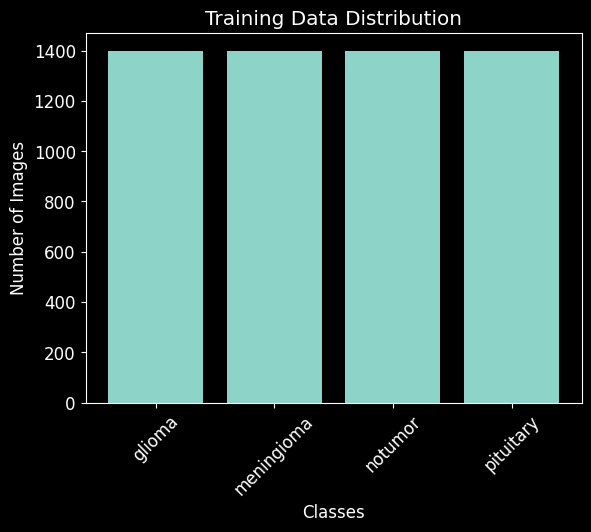

glioma: 1400
meningioma: 1400
notumor: 1400
pituitary: 1400


In [40]:
import matplotlib.pyplot as plt

unique, counts = np.unique(train_labels, return_counts=True)

plt.figure()
plt.bar(unique, counts)
plt.title("Training Data Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

for u, c in zip(unique, counts):
    print(f"{u}: {c}")

This code visualizes the distribution of classes within the training dataset using a bar plot. It counts the occurrences of each unique label and displays them graphically and numerically.

## Visualize Testing Class Distribution

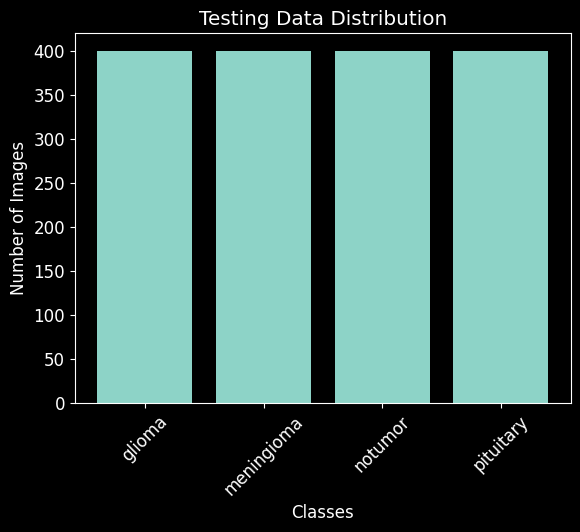

glioma: 400
meningioma: 400
notumor: 400
pituitary: 400


In [41]:
unique_t, counts_t = np.unique(test_labels, return_counts=True)

plt.figure()
plt.bar(unique_t, counts_t)
plt.title("Testing Data Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

for u, c in zip(unique_t, counts_t):
    print(f"{u}: {c}")

This cell performs a similar class distribution visualization for the testing dataset as was done for the training set, showing the number of images per class.

## Sample Image Visualization

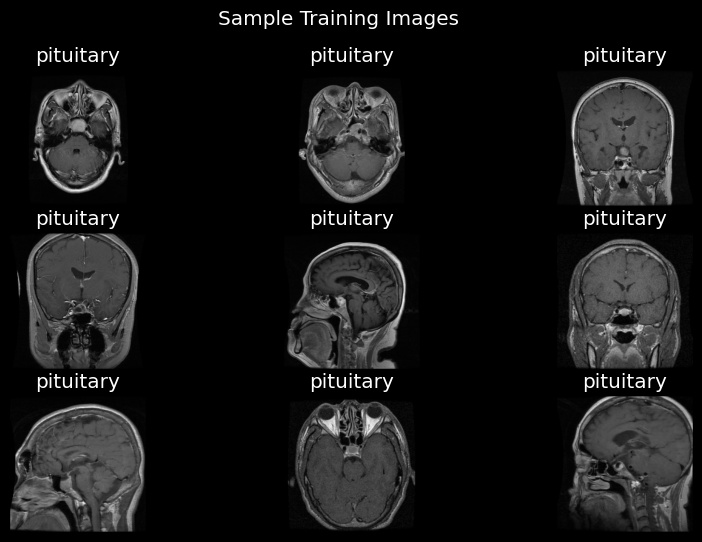

In [42]:
plt.figure(figsize=(10, 6))

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(train_labels[i])
    plt.axis('off')

plt.suptitle("Sample Training Images")
plt.show()

This cell displays a grid of 9 sample images from the training dataset along with their respective labels, offering a visual inspection of the input data.

## Plot Image Pixel Intensity Distribution

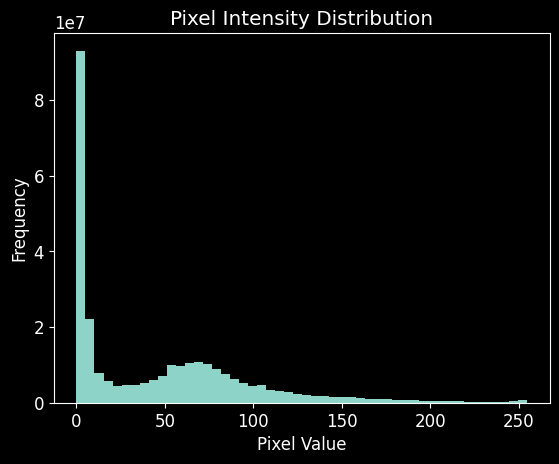

In [43]:
all_pixels = train_images.flatten()

plt.figure()
plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

This code flattens all training image pixels into a single array and then plots a histogram to show the distribution of pixel intensity values across the entire dataset.

## Verify Image Dimensions

In [44]:
heights = [img.shape[0] for img in train_images]
widths  = [img.shape[1] for img in train_images]

print("Unique Heights:", set(heights))
print("Unique Widths :", set(widths))


Unique Heights: {224}
Unique Widths : {224}


This cell verifies that all images in the training dataset have consistent dimensions (height and width) after resizing, printing the unique values found for each dimension.

## Visualize One Sample Per Class

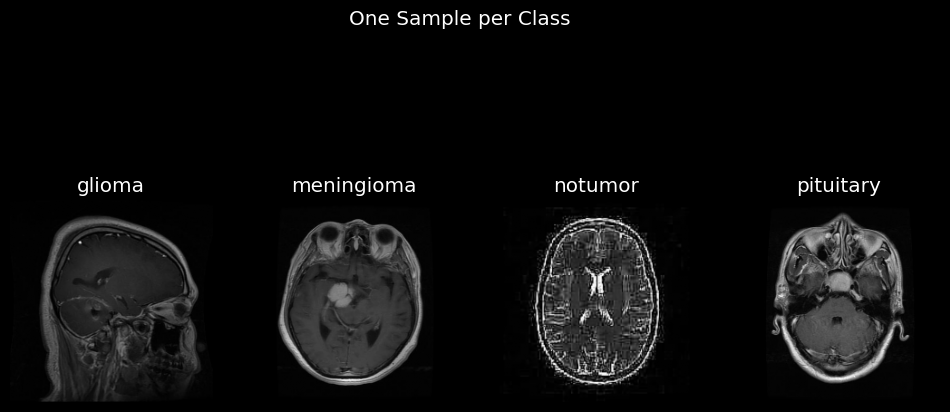

In [45]:
classes = np.unique(train_labels)

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    idx = np.where(train_labels == cls)[0][0]

    plt.subplot(1, len(classes), i+1)
    plt.imshow(train_images[idx], cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.suptitle("One Sample per Class")
plt.show()

This code block visualizes one representative image for each unique class present in the training dataset, providing a clear example of what each class looks like.

# **ML MODEL STARTS**

## Extract HOG Features

In [46]:
from skimage.feature import hog
from sklearn.svm import SVC
def extract_hog(images):
    features = []

    for img in tqdm(images):
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feature)

    return np.array(features)

X_train = extract_hog(train_images)
X_test  = extract_hog(test_images)

print("HOG Train Shape:", X_train.shape)
print("HOG Test Shape:", X_test.shape)

100%|██████████| 1600/1600 [00:28<00:00, 56.03it/s]


HOG Train Shape: (5600, 26244)
HOG Test Shape: (1600, 26244)


This cell defines a function to extract Histogram of Oriented Gradients (HOG) features from images. It then applies this function to both training and test image sets and prints the shapes of the resulting HOG feature arrays.

## Perform Label Encoding

In [47]:
le = LabelEncoder()

y_train = le.fit_transform(train_labels)
y_test  = le.transform(test_labels)

print("Classes:", le.classes_)

Classes: ['glioma' 'meningioma' 'notumor' 'pituitary']


This cell uses `LabelEncoder` to convert categorical text labels (e.g., 'glioma', 'notumor') into numerical labels, which are required for machine learning models. It fits the encoder on training labels and transforms both training and test labels.

## Initialize Machine Learning Models

In [48]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

This cell initializes a dictionary of various machine learning models (K-Nearest Neighbors, Support Vector Machine, Random Forest, Decision Tree, and Logistic Regression) with their respective default or chosen parameters.

## Train and Evaluate ML Models

In [49]:
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))


===== KNN =====
Accuracy: 0.835
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.73      0.80       400
           1       0.87      0.65      0.74       400
           2       0.76      0.99      0.86       400
           3       0.86      0.97      0.91       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600


===== SVM =====
Accuracy: 0.899375
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.72      0.82       400
           1       0.84      0.91      0.88       400
           2       0.87      1.00      0.93       400
           3       0.96      0.96      0.96       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600


===== Random

This code iterates through each defined machine learning model, trains it on the HOG features of the training data (`X_train`, `y_train`), makes predictions on the test data (`X_test`), and then calculates and prints the accuracy and a detailed classification report for each model.

## Plot Confusion Matrices (ML Models)

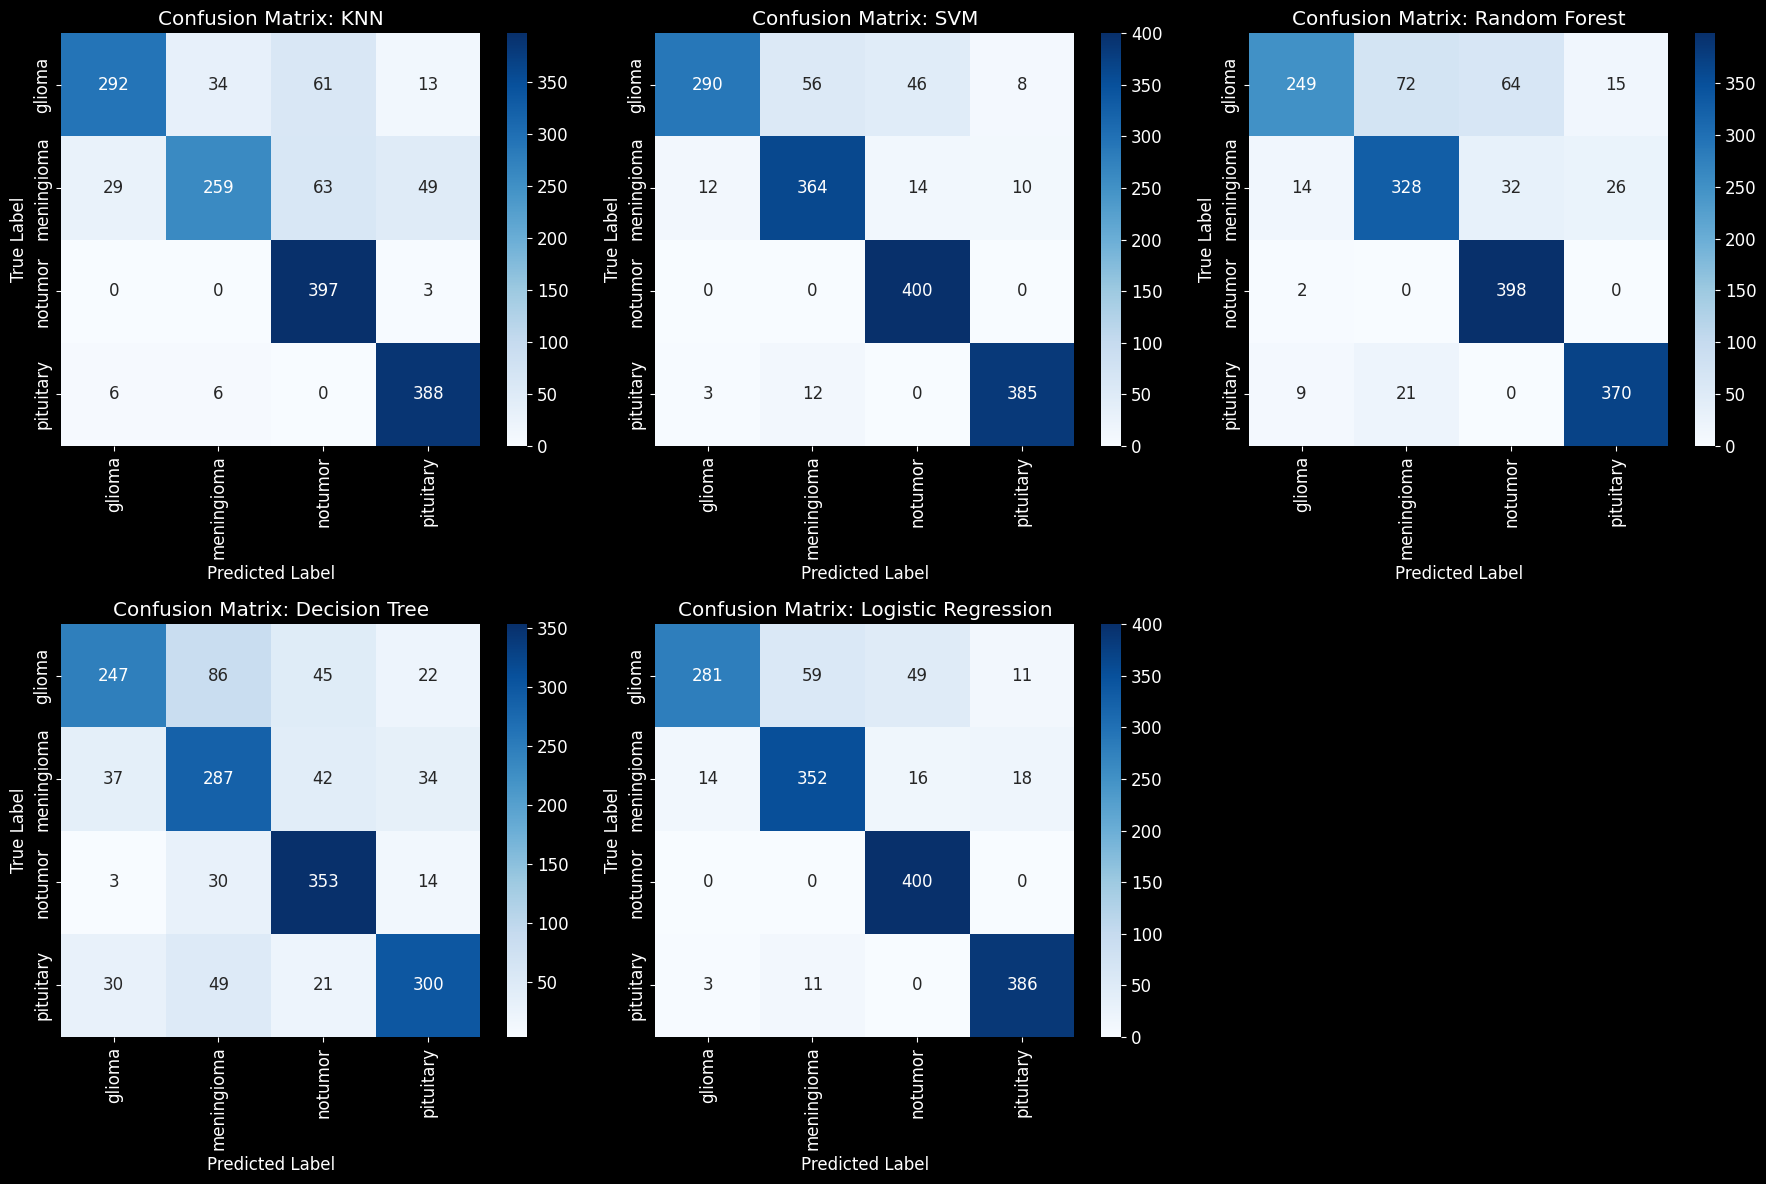

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set up the figure grid (2 rows, 3 columns to fit 5 models)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Get predictions
    y_pred = model.predict(X_test)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot using seaborn
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)

    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

This cell generates and displays confusion matrices for each trained machine learning model. A confusion matrix helps visualize the performance of a classification model, showing true positives, true negatives, false positives, and false negatives for each class.

## Visualize ML Model Performance Metrics

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison_data = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create DataFrame
df_compare = pd.DataFrame(comparison_data).sort_values(by="Accuracy", ascending=False)
print(df_compare)

                 Model  Accuracy  Precision    Recall  F1-Score
1                  SVM  0.899375   0.904578  0.899375  0.896708
4  Logistic Regression  0.886875   0.891853  0.886875  0.883425
2        Random Forest  0.840625   0.848442  0.840625  0.835183
0                  KNN  0.835000   0.844424  0.835000  0.829049
3        Decision Tree  0.741875   0.747668  0.741875  0.740472


This code calculates and compiles accuracy, precision, recall, and F1-score for each machine learning model on the test set. The results are stored in a Pandas DataFrame and printed, providing a tabular comparison of model performance.

## ML Model Performance Comparison

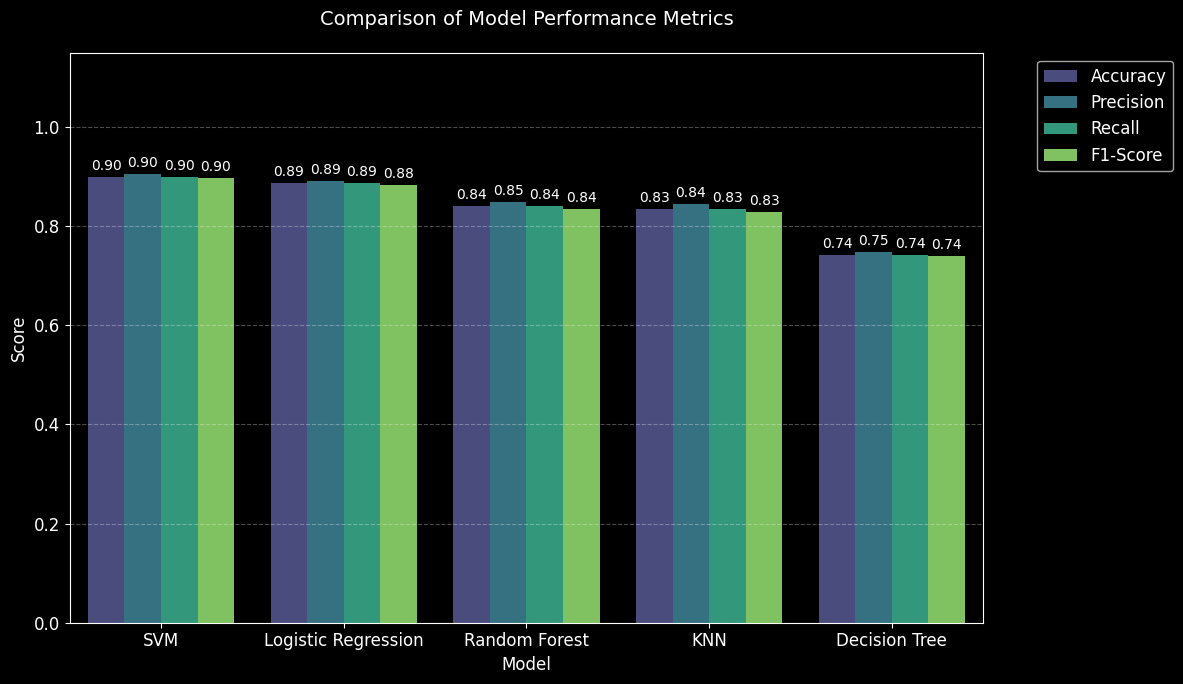

In [52]:
# Melt the dataframe for easier plotting
df_melted = df_compare.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
# Create the barplot and capture the axis object 'ax'
ax = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="viridis")

# Add the values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Comparison of Model Performance Metrics", fontsize=14, pad=20)
plt.ylim(0, 1.15) # Increased limit to make room for labels
plt.ylabel("Score")
plt.xlabel("Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This cell visualizes the performance metrics (Accuracy, Precision, Recall, F1-Score) of the machine learning models using a grouped bar plot, making it easy to compare their effectiveness.

## Plot ROC Curve Comparison for ML Models

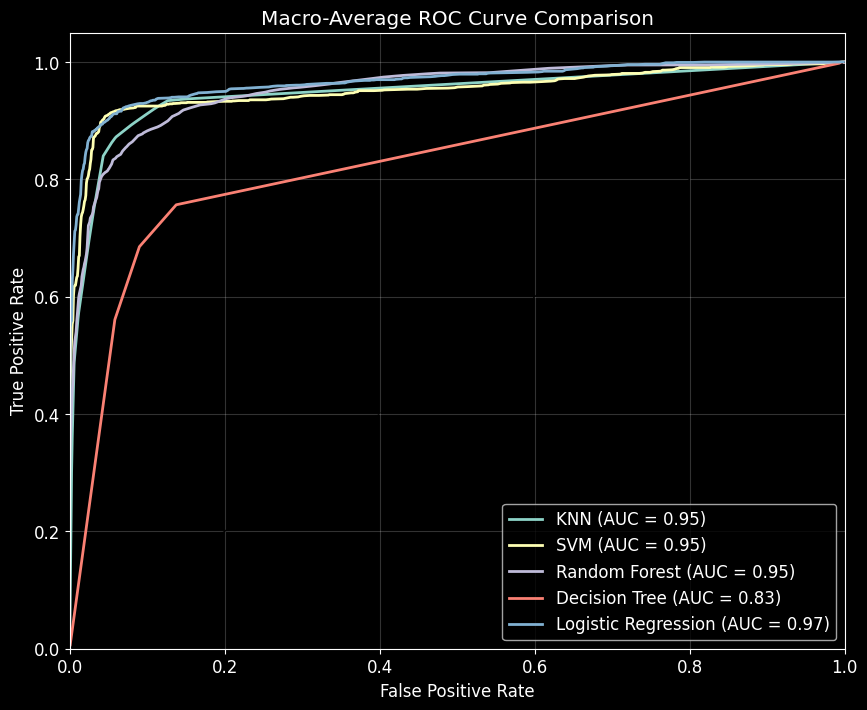

In [53]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))

# 2. Loop through each model to calculate and plot ROC
for name, model in models.items():
    # Use predict_proba for models that support it, otherwise use decision_function (for SVM)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    # Compute ROC curve and ROC area for each class, then average them (Macro-average)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Aggregate all false positive rates
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes

    # Calculate Macro AUC
    macro_auc = auc(all_fpr, mean_tpr)

    # Plot the curve
    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:.2f})', lw=2)

# 3. Final Plot Formatting
plt.plot([0, 1], [0, 1], 'k--', lw=1) # Random chance line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

This code plots the Macro-Average Receiver Operating Characteristic (ROC) curves for each machine learning model. The ROC curve illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied, and AUC (Area Under the Curve) provides a single number summary of the curve.

# **DL Models**

## Check for GPU Device Availability

In [54]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


I0000 00:00:1776064825.103488     265 gpu_device.cc:2019] Created device /device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776064825.104958     265 gpu_device.cc:2019] Created device /device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


This cell checks for the availability of a GPU device in the environment using TensorFlow. It prints a message indicating whether a GPU is found, which is crucial for accelerating deep learning computations.

## Prepare Training Image Paths and Labels

In [55]:
from sklearn.utils import shuffle

train_paths = []
train_labels = []

for label in os.listdir(TRAIN_PATH):
    class_path = os.path.join(TRAIN_PATH, label)

    # Skip non-directories (safety for Kaggle)
    if not os.path.isdir(class_path):
        continue

    for image in os.listdir(class_path):
        img_path = os.path.join(class_path, image)

        train_paths.append(img_path)
        train_labels.append(label)

# Shuffle data
train_paths, train_labels = shuffle(train_paths, train_labels, random_state=42)

print("Total training images:", len(train_paths))

Total training images: 5600


This cell prepares the file paths and corresponding labels for the training images specifically for deep learning models. It shuffles the data to ensure randomness during training and prints the total number of training images found.

## Prepare Training Data Paths (DL)

In [56]:
from sklearn.utils import shuffle

test_paths = []
test_labels = []

# Loop through the TEST_PATH to grab the file locations
for label in os.listdir(TEST_PATH):
    class_path = os.path.join(TEST_PATH, label)
    if not os.path.isdir(class_path):
        continue
    for image in os.listdir(class_path):
        img_path = os.path.join(class_path, image)
        test_paths.append(img_path)
        test_labels.append(label)

print("Total testing images found:", len(test_paths))

Total testing images found: 1600


This cell prepares the file paths and corresponding labels for the testing images, similar to how the training data paths were prepared. It iterates through the test directory structure and stores image paths and labels.

## Define Image Augmentation Function

In [57]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    image = np.array(image)/255.0
    return image

This function defines an image augmentation pipeline, which applies random brightness and contrast adjustments to an input image, and normalizes pixel values. This helps in making deep learning models more robust to variations in input data.

## Implement Custom Data Generator

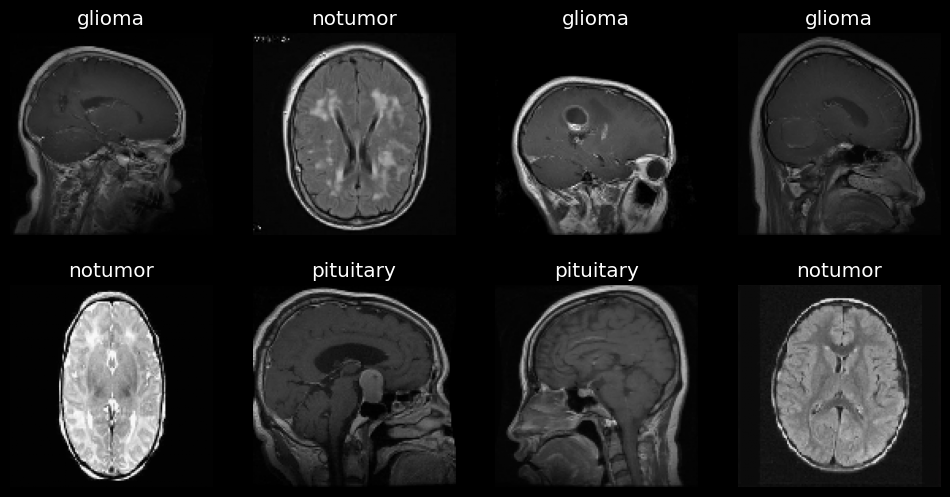

In [58]:
IMAGE_SIZE = 128

def open_images(paths):
    '''
    Given a list of paths to images, this function returns the images as arrays (after augmenting them)
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE,IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

images = open_images(train_paths[50:59])
labels = train_labels[50:59]
fig = plt.figure(figsize=(12, 6))
for x in range(1, 9):
    fig.add_subplot(2, 4, x)
    plt.axis('off')
    plt.title(labels[x])
    plt.imshow(images[x])
plt.rcParams.update({'font.size': 12})
plt.show()

This code demonstrates the `augment_image` function by loading a few sample images, applying the augmentation, and displaying them. This visual check confirms that the augmentation is working as expected.

## Construct VGG16 Transfer Learning Model

In [59]:
unique_labels = os.listdir(TRAIN_PATH)

def encode_label(labels):
    encoded = []
    for x in labels:
        encoded.append(unique_labels.index(x))
    return np.array(encoded)

def decode_label(labels):
    decoded = []
    for x in labels:
        decoded.append(unique_labels[x])
    return np.array(decoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for x in range(0, len(paths), batch_size):
            batch_paths = paths[x:x+batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[x:x+batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

This cell defines utility functions: `encode_label` to convert string labels to numerical indices and `decode_label` to convert numerical indices back to string labels. It also defines `datagen`, a custom data generator, which yields batches of augmented images and encoded labels for training deep learning models.

## Display VGG16 Model Summary

In [60]:
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), include_top=False, weights='imagenet')
# Set all layers to non-trainable
for layer in base_model.layers:
    layer.trainable = False
# Set the last vgg block to trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(unique_labels), activation='softmax'))

This cell constructs a VGG16-based transfer learning model. It loads a pre-trained VGG16 model without its top classification layers, freezes most of its layers, unfreezes the last few convolutional layers for fine-tuning, and adds custom dense layers for classification.

## VGG16 Model Summary

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,908 (60.13 MB)

 Trainable params: 8,128,644 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

This command displays a summary of the constructed VGG16 model, including its layers, output shapes, and the number of trainable and non-trainable parameters.

## Compile VGG16 Model

In [62]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss='sparse_categorical_crossentropy',
             metrics=['sparse_categorical_accuracy'])

This cell compiles the VGG16 model, specifying the Adam optimizer with a given learning rate, sparse categorical cross-entropy as the loss function, and sparse categorical accuracy as the evaluation metric.

## Train VGG16 Model with Callbacks

In [80]:
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Setup the checkpoint
checkpoint = ModelCheckpoint(
    'best_vgg16_model.keras',   # Name of the file to save
    monitor='sparse_categorical_accuracy', # What to watch
    save_best_only=True,        # Only overwrite if accuracy improves
    mode='max',                 # We want the maximum accuracy
    verbose=1
)

# 2. Run training with the callback
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[checkpoint] # <--- Add this line!
)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0157 - sparse_categorical_accuracy: 0.9941
Epoch 1: sparse_categorical_accuracy improved from -inf to 0.99232, saving model to best_vgg16_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 66ms/step - loss: 0.0158 - sparse_categorical_accuracy: 0.9941
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0469 - sparse_categorical_accuracy: 0.9826
Epoch 2: sparse_categorical_accuracy did not improve from 0.99232
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 0.0469 - sparse_categorical_accuracy: 0.9826
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0224 - sparse_categorical_accuracy: 0.9934
Epoch 3: sparse_categorical_accuracy did not improve from 0.99232
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - loss: 0.0224 - sparse_categorical_accuracy: 0.9934
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0126 - sparse_categorical_accuracy: 0.9949
Epoch 4: sparse_categorical_accuracy improved fro

This code trains the VGG16 model using the custom data generator. It also includes a `ModelCheckpoint` callback to save the model weights that achieve the best validation accuracy during training.

## Evaluate Best Saved VGG16 Model

In [81]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report

# 1. Load the saved "best" model
best_model = tf.keras.models.load_model('best_vgg16_model.keras')

# 2. Setup the test generator
# Using a batch size that fits 1600 evenly (e.g., 32)
batch_size = 32
test_steps = len(test_paths) // batch_size

test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# 3. Predict
print("Evaluating the best saved model...")
y_pred_probs = best_model.predict(test_gen, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get matching true labels
# We slice test_labels to match the exact number of predictions made
y_true = encode_label(test_labels[:len(y_pred)])

# 5. Print the final report
print("\nClassification Report for Best Model:")
print(classification_report(y_true, y_pred, target_names=unique_labels))

Evaluating the best saved model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step

Classification Report for Best Model:
              precision    recall  f1-score   support

   pituitary       0.99      0.97      0.98       400
     notumor       0.93      1.00      0.96       400
  meningioma       0.85      0.98      0.91       400
      glioma       0.98      0.78      0.87       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



This cell evaluates the performance of the best saved VGG16 model on the test dataset. It loads the best model, uses the data generator to get test predictions, and then prints a classification report with precision, recall, and F1-score for each class.

## Visualize VGG16 Confusion Matrix

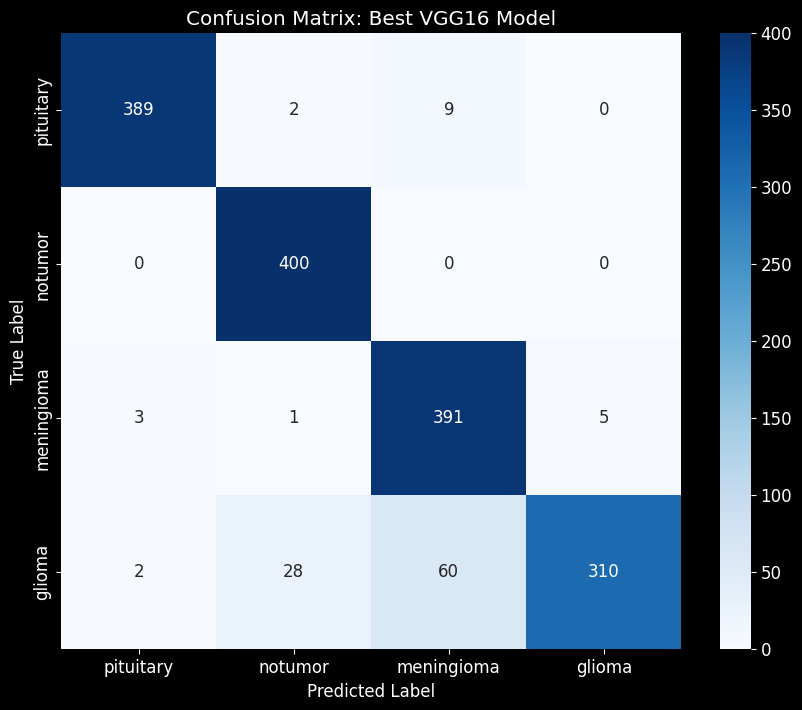

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 2. Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels)

plt.title('Confusion Matrix: Best VGG16 Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This cell visualizes the confusion matrix for the VGG16 model's predictions on the test set. It uses Seaborn to create a heatmap, making it easy to see how well the model classified each class and where it made errors.

# ResNet50

## Construct ResNet50 Transfer Learning Model

In [66]:
from tensorflow.keras.applications import ResNet50

# 1. Load ResNet50 base
resnet_base = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                       include_top=False,
                       weights='imagenet')

# 2. Freeze all layers initially
for layer in resnet_base.layers:
    layer.trainable = False

# 3. Unfreeze the last few layers for fine-tuning
# ResNet50 has many layers; unfreezing the last 'conv5_block3' (approx last 7 layers)
for layer in resnet_base.layers[-7:]:
    layer.trainable = True

# 4. Build the Sequential model
resnet_model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    resnet_base,
    Flatten(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(unique_labels), activation='softmax')
])

# 5. Compile
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,141,060 (122.61 MB)

 Trainable params: 11,903,364 (45.41 MB)

 Non-trainable params: 20,237,696 (77.20 MB)

This cell constructs a ResNet50-based transfer learning model. It loads a pre-trained ResNet50 model, freezes most of its layers, then unfreezes the last few blocks for fine-tuning, and adds custom dense layers for the final classification.

## Compile ResNet50 Model

In [67]:
# Compile the ResNet50 model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

This cell compiles the ResNet50 model with the Adam optimizer, sparse categorical cross-entropy loss, and sparse categorical accuracy metric. This prepares the model for its initial training phase.

## Train ResNet50 Model with Checkpoint

In [68]:
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Setup the checkpoint for ResNet
resnet_checkpoint = ModelCheckpoint(
    'best_resnet50_model.keras',
    monitor='sparse_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Run training (Using your existing datagen and paths)
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10

resnet_history = resnet_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[resnet_checkpoint]
)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 1.0938 - sparse_categorical_accuracy: 0.5707
Epoch 1: sparse_categorical_accuracy improved from -inf to 0.62982, saving model to best_resnet50_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - loss: 1.0933 - sparse_categorical_accuracy: 0.5709
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.7964 - sparse_categorical_accuracy: 0.6859
Epoch 2: sparse_categorical_accuracy improved from 0.62982 to 0.70107, saving model to best_resnet50_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - loss: 0.7963 - sparse_categorical_accuracy: 0.6860
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.6772 - sparse_categorical_accuracy: 0.7205
Epoch 3: sparse_categorical_accuracy improved from 0.70107 to 0.72679, saving model to best_resnet50_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - loss: 0.6771 - sparse_categorical_accuracy: 0.7206
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - los

This code trains the initial ResNet50 model using the data generator. A `ModelCheckpoint` callback is used to save the version of the model with the highest sparse categorical accuracy achieved during this training phase.

## Evaluate Initial ResNet50 Model Performance

In [69]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the best saved ResNet50 model
best_resnet_model = tf.keras.models.load_model('best_resnet50_model.keras')

# 2. Setup the test generator
batch_size = 32
test_steps = len(test_paths) // batch_size
test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# 3. Generate Predictions
print("Evaluating the best ResNet50 model...")
y_pred_probs = best_resnet_model.predict(test_gen, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get matching true labels
y_true = encode_label(test_labels[:len(y_pred)])

# 5. Print Classification Report
print("\nResNet50 Classification Report:")
print(classification_report(y_true, y_pred, target_names=unique_labels))



Evaluating the best ResNet50 model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step

ResNet50 Classification Report:
              precision    recall  f1-score   support

   pituitary       0.92      0.19      0.32       400
     notumor       0.86      0.56      0.68       400
  meningioma       0.40      0.40      0.40       400
      glioma       0.38      0.82      0.52       400

    accuracy                           0.49      1600
   macro avg       0.64      0.49      0.48      1600
weighted avg       0.64      0.49      0.48      1600



This cell evaluates the performance of the best saved ResNet50 model (after initial training) on the test dataset, similar to the VGG16 evaluation. It loads the model, generates predictions, and prints a classification report.

## Fine-Tune ResNet50: Unfreeze and Recompile Last Blocks

In [70]:
# 1. Unfreeze the base model
resnet_base.trainable = True

# 2. Refreeze everything EXCEPT the last two blocks (block 4 and 5)
# This allows the model to learn more complex spatial features
for layer in resnet_base.layers[:143]:
    layer.trainable = False

# 3. Re-compile with a VERY small learning rate
# We use 1e-5 (0.00001) so we don't "break" the pre-trained weights
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,141,060 (122.61 MB)

 Trainable params: 11,903,364 (45.41 MB)

 Non-trainable params: 20,237,696 (77.20 MB)

This cell prepares the ResNet50 model for fine-tuning by unfreezing a specific set of layers (the last two blocks) within the base model. It then recompiles the model with a very small learning rate to prevent large weight updates during fine-tuning.

## Train Fine-Tuned ResNet50 Model

In [83]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# Checkpoint to save the best version during fine-tuning
fine_tune_checkpoint = ModelCheckpoint(
    'resnet50_finetuned.keras',
    monitor='sparse_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Learning rate scheduler
lr_reducer = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, verbose=1)

# Training
batch_size = 20
steps = int(len(train_paths) / batch_size)

print("Starting Fine-Tuning...")
resnet_ft_history = resnet_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=10),
    epochs=10,
    steps_per_epoch=steps,
    callbacks=[fine_tune_checkpoint, lr_reducer]
)

Starting Fine-Tuning...
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2561 - sparse_categorical_accuracy: 0.8998
Epoch 1: sparse_categorical_accuracy improved from -inf to 0.90232, saving model to resnet50_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - loss: 0.2561 - sparse_categorical_accuracy: 0.8998 - learning_rate: 2.5000e-07
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.2573 - sparse_categorical_accuracy: 0.9055
Epoch 2: sparse_categorical_accuracy improved from 0.90232 to 0.90304, saving model to resnet50_finetuned.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.2573 - sparse_categorical_accuracy: 0.9055 - learning_rate: 2.5000e-07
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2601 - sparse_categorical_accuracy: 0.8918
Epoch 3: sparse_categorical_accuracy did not improve from 0.90304
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.2601 - sparse_categorical_accuracy: 0.8919 - learning_rate: 2.5000e-07

This code continues training the ResNet50 model, now with a fine-tuned approach, allowing more layers to learn. It includes `ModelCheckpoint` to save the best model and `ReduceLROnPlateau` to dynamically adjust the learning rate during training.

## Evaluate Fine-Tuned ResNet50 Model

Evaluating the Fine-Tuned ResNet50 model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step

Fine-Tuned ResNet50 Classification Report:
              precision    recall  f1-score   support

   pituitary       0.92      0.92      0.92       400
     notumor       0.81      0.98      0.89       400
  meningioma       0.77      0.74      0.76       400
      glioma       0.80      0.66      0.72       400

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.82      1600
weighted avg       0.82      0.82      0.82      1600



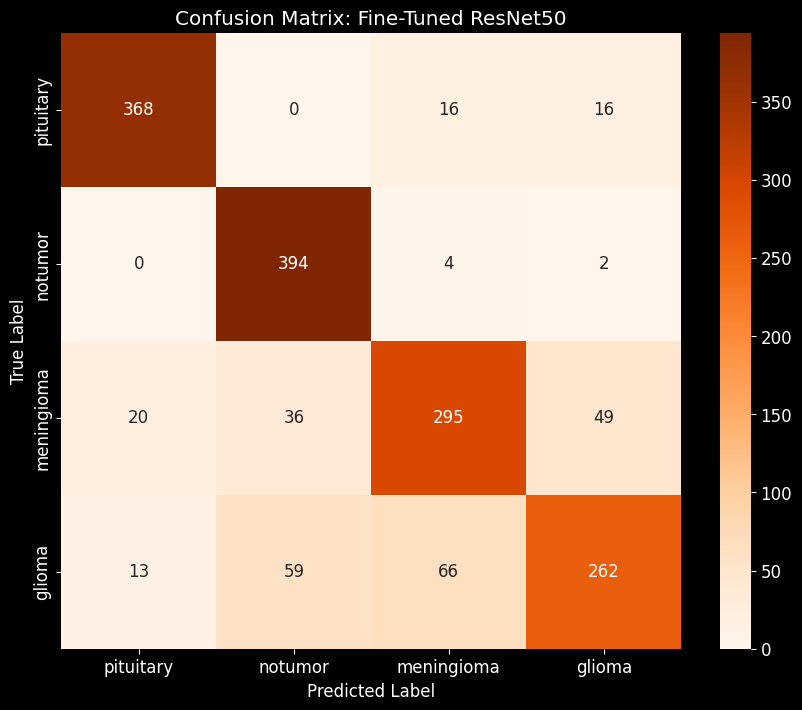

In [84]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the fine-tuned model
# This is the file name we used in the ModelCheckpoint during fine-tuning
ft_model = tf.keras.models.load_model('resnet50_finetuned.keras')

# 2. Setup the test generator
batch_size = 32
test_steps = len(test_paths) // batch_size
test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# 3. Generate Predictions
print("Evaluating the Fine-Tuned ResNet50 model...")
y_pred_probs = ft_model.predict(test_gen, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get matching true labels
y_true = encode_label(test_labels[:len(y_pred)])

# 5. Print Classification Report
print("\nFine-Tuned ResNet50 Classification Report:")
print(classification_report(y_true, y_pred, target_names=unique_labels))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix: Fine-Tuned ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This cell evaluates the performance of the fine-tuned ResNet50 model on the test dataset. It loads the best fine-tuned model, generates predictions, displays a classification report, and plots the confusion matrix.

# Unfreeze the ENTIRE base model

In [85]:
# 1. Unfreeze the ENTIRE base model
resnet_base.trainable = True

# 2. Re-compile with an even smaller learning rate
# 1e-6 is extremely small, allowing for "micro-adjustments" across all 50 layers
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32768)          │       131,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,141,060 (122.61 MB)

 Trainable params: 11,903,364 (45.41 MB)

 Non-trainable params: 20,237,696 (77.20 MB)

This cell takes the ResNet50 model to the next level of fine-tuning by unfreezing *all* layers of the base model. It then recompiles the model with an even smaller learning rate (1e-6) to make subtle adjustments across the entire network.

## Train Fully Unlocked ResNet50 Model with Early Stopping

In [86]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Checkpoint for the fully unlocked model
final_checkpoint = ModelCheckpoint(
    'resnet50_fully_unlocked.keras',
    monitor='sparse_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stop if accuracy stops improving for 3 epochs
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Training
batch_size = 20
steps = int(len(train_paths) / batch_size)

print("Starting Full Model Unlocking...")
final_history = resnet_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=15),
    epochs=15,
    steps_per_epoch=steps,
    callbacks=[final_checkpoint, lr_reducer, early_stop]
)

Starting Full Model Unlocking...
Epoch 1/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2563 - sparse_categorical_accuracy: 0.8971
Epoch 1: sparse_categorical_accuracy improved from -inf to 0.90107, saving model to resnet50_fully_unlocked.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - loss: 0.2563 - sparse_categorical_accuracy: 0.8972 - learning_rate: 1.0000e-06
Epoch 2/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.2604 - sparse_categorical_accuracy: 0.8987
Epoch 2: sparse_categorical_accuracy improved from 0.90107 to 0.90196, saving model to resnet50_fully_unlocked.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 0.2603 - sparse_categorical_accuracy: 0.8987 - learning_rate: 1.0000e-06
Epoch 3/15
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2622 - sparse_categorical_accuracy: 0.8985
Epoch 3: sparse_categorical_accuracy did not improve from 0.90196

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999987376214e-07.
280/280 ━━━━━━━━━━━━━━━━━━━

This code block trains the fully unlocked ResNet50 model with the extremely small learning rate. It utilizes `ModelCheckpoint` and `ReduceLROnPlateau` callbacks, and additionally incorporates `EarlyStopping` to prevent overfitting by monitoring the loss.

## Evaluate Fully Unlocked ResNet50 Model

Evaluating the Fully Unlocked ResNet50 model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step

Final ResNet50 Classification Report (Fully Unlocked):
              precision    recall  f1-score   support

   pituitary       0.90      0.93      0.91       400
     notumor       0.81      0.99      0.89       400
  meningioma       0.78      0.69      0.74       400
      glioma       0.77      0.66      0.71       400

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.81      1600
weighted avg       0.82      0.82      0.81      1600



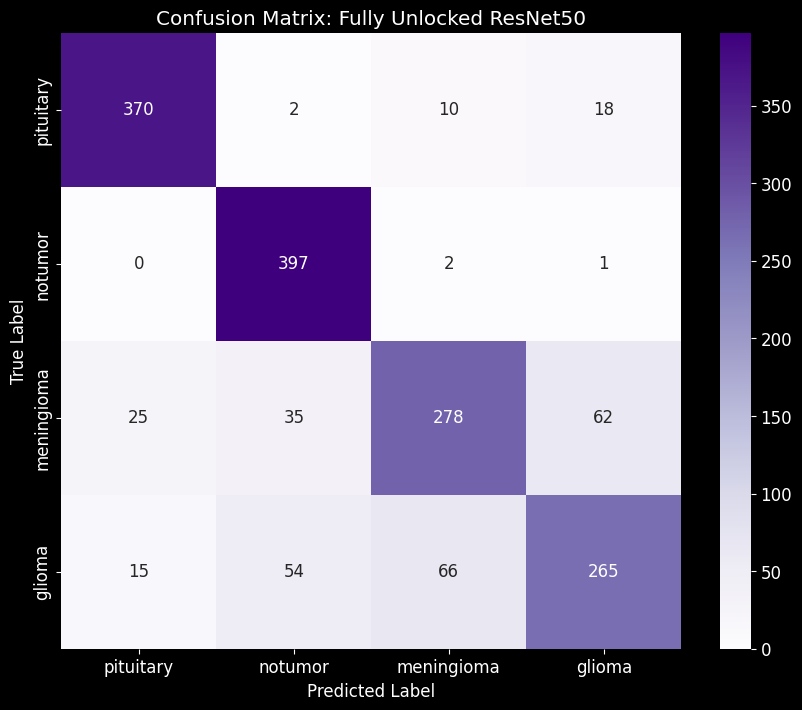

In [87]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the fully unlocked model
final_model = tf.keras.models.load_model('resnet50_fully_unlocked.keras')

# 2. Setup the test generator
batch_size = 32
test_steps = len(test_paths) // batch_size
test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# 3. Generate Predictions
print("Evaluating the Fully Unlocked ResNet50 model...")
y_pred_probs = final_model.predict(test_gen, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get matching true labels
y_true = encode_label(test_labels[:len(y_pred)])

# 5. Print Classification Report
print("\nFinal ResNet50 Classification Report (Fully Unlocked):")
print(classification_report(y_true, y_pred, target_names=unique_labels))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix: Fully Unlocked ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This cell evaluates the final fully unlocked ResNet50 model on the test dataset. It loads the best saved model from this phase, generates predictions, and presents a comprehensive classification report and confusion matrix to assess its ultimate performance.

# Coustom CNN

## Build Custom CNN Model

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D

custom_model = Sequential([
    # Input Layer
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    # Block 1: Initial feature extraction
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Block 2: Capturing more complex shapes
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Block 3: Deep feature mapping
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    # Block 4: Final conv block
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling2D(), # Better than Flatten for reducing overfitting

    # Fully Connected Layers
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(unique_labels), activation='softmax')
])

# Compile with a standard learning rate to start
custom_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

custom_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 503,716 (1.92 MB)

 Trainable params: 502,564 (1.92 MB)

 Non-trainable params: 1,152 (4.50 KB)

This cell defines a custom Convolutional Neural Network (CNN) architecture from scratch. It includes multiple convolutional blocks with batch normalization, max pooling, dropout, and a global average pooling layer before the final dense classification layers.

## Train Custom CNN Model

In [88]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Checkpoint for Custom CNN
custom_checkpoint = ModelCheckpoint(
    'best_custom_cnn.keras',
    monitor='sparse_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stop if the model stops learning to save time
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

# Training configuration
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 10 # Custom models often need more epochs than Transfer Learning

print("Starting Custom CNN Training...")
custom_history = custom_model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[custom_checkpoint, early_stop]
)

Starting Custom CNN Training...
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0832 - sparse_categorical_accuracy: 0.9694
Epoch 1: sparse_categorical_accuracy improved from -inf to 0.97018, saving model to best_custom_cnn.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - loss: 0.0832 - sparse_categorical_accuracy: 0.9694
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0776 - sparse_categorical_accuracy: 0.9708
Epoch 2: sparse_categorical_accuracy improved from 0.97018 to 0.97286, saving model to best_custom_cnn.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - loss: 0.0776 - sparse_categorical_accuracy: 0.9708
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0516 - sparse_categorical_accuracy: 0.9845
Epoch 3: sparse_categorical_accuracy improved from 0.97286 to 0.97929, saving model to best_custom_cnn.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 15s 53ms/step - loss: 0.0516 - sparse_categorical_accuracy: 0.9845
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━

This code trains the custom CNN model using the data generator. It includes `ModelCheckpoint` to save the best performing model and `EarlyStopping` to stop training if the loss doesn't improve for a specified number of epochs.

## Evaluate Custom CNN Model

Evaluating the Custom CNN model...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step

Custom CNN Classification Report:
              precision    recall  f1-score   support

   pituitary       0.98      0.92      0.95       400
     notumor       0.83      1.00      0.91       400
  meningioma       0.96      0.83      0.89       400
      glioma       0.84      0.83      0.84       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



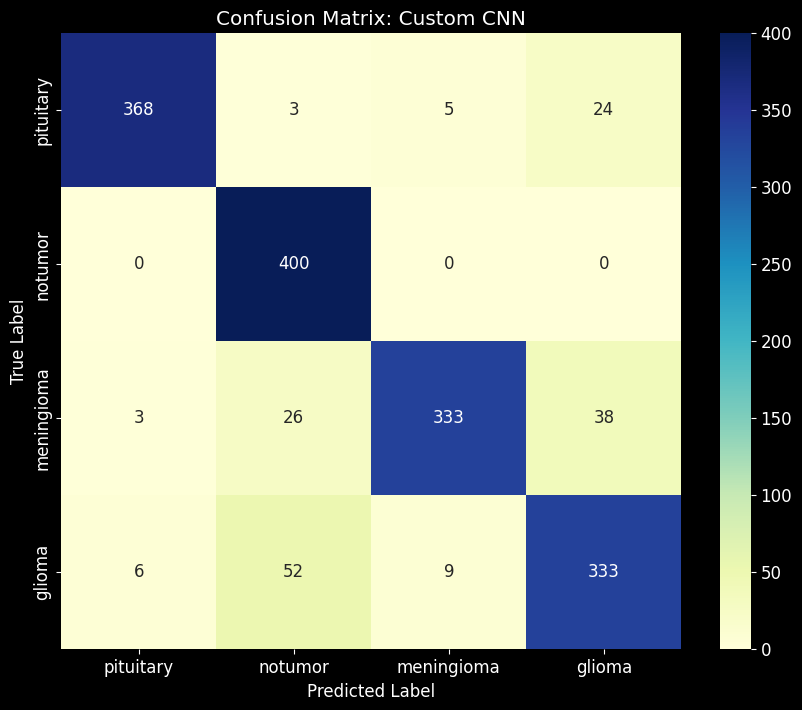

In [90]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the best saved Custom CNN model
final_custom_model = tf.keras.models.load_model('best_custom_cnn.keras')

# 2. Setup the test generator
# Using batch_size=32 to evaluate the 1600 test images efficiently
batch_size = 32
test_steps = len(test_paths) // batch_size
test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

# 3. Generate Predictions
print("Evaluating the Custom CNN model...")
y_pred_probs = final_custom_model.predict(test_gen, steps=test_steps)
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Get matching true labels
y_true = encode_label(test_labels[:len(y_pred)])

# 5. Print Classification Report
print("\nCustom CNN Classification Report:")
print(classification_report(y_true, y_pred, target_names=unique_labels))

# 6. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix: Custom CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

This cell evaluates the performance of the best saved custom CNN model on the test dataset. It loads the model, makes predictions, and then displays the classification report and a confusion matrix to illustrate its classification accuracy and errors.

## Deep Learning Model Performance Comparison

In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# List of your saved model files and their display names
dl_models_info = {
    "VGG16": "best_vgg16_model.keras",
    "ResNet50": "resnet50_fully_unlocked.keras",
    "Custom CNN": "best_custom_cnn.keras"
}

dl_comparison_data = []

for name, file_path in dl_models_info.items():
    print(f"Evaluating {name}...")

    # Load model
    temp_model = tf.keras.models.load_model(file_path)

    # Prepare test data (ensuring same batch size and steps as your previous evaluations)
    batch_size = 32
    test_steps = len(test_paths) // batch_size
    test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

    # Predict
    y_pred_probs = temp_model.predict(test_gen, steps=test_steps, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Get matching true labels
    y_true = encode_label(test_labels[:len(y_pred)])

    # Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    dl_comparison_data.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# Create DataFrame
df_dl_compare = pd.DataFrame(dl_comparison_data).sort_values(by="Accuracy", ascending=False)
print("\nDeep Learning Model Comparison:")
print(df_dl_compare)

Evaluating VGG16...
Evaluating ResNet50...
Evaluating Custom CNN...

Deep Learning Model Comparison:
        Model  Accuracy  Precision    Recall  F1-Score
0       VGG16  0.930625   0.936245  0.930625  0.929011
2  Custom CNN  0.895000   0.903064  0.895000  0.895255
1    ResNet50  0.820000   0.817057  0.820000  0.814513


This cell systematically evaluates all trained deep learning models (VGG16, ResNet50, Custom CNN) on the test dataset. It loads each model, calculates accuracy, precision, recall, and F1-score, and then compiles these metrics into a Pandas DataFrame for comparison.

## Visualize DL Model Performance Metrics

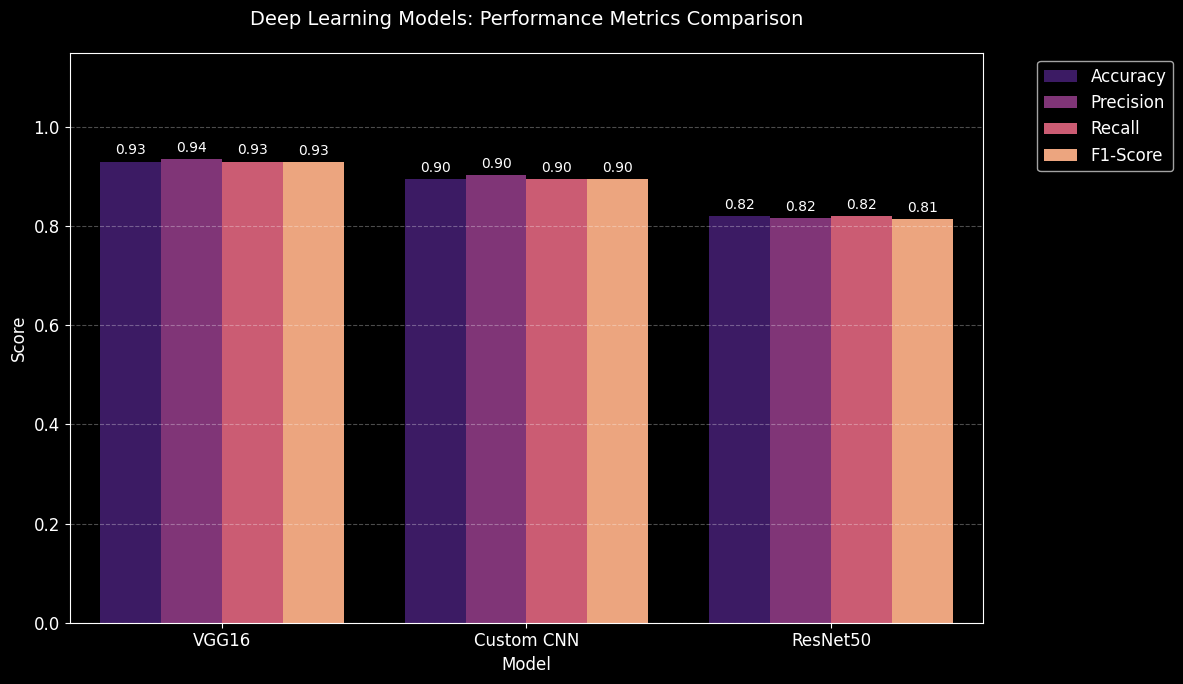

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe for plotting
df_dl_melted = df_dl_compare.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=df_dl_melted, x="Model", y="Score", hue="Metric", palette="magma")

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Deep Learning Models: Performance Metrics Comparison", fontsize=14, pad=20)
plt.ylim(0, 1.15)
plt.ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

This cell visualizes the performance metrics (Accuracy, Precision, Recall, F1-Score) of the deep learning models using a grouped bar plot. This plot provides a clear side-by-side comparison of how each DL model performed across different metrics.

## ROC Curve Comparison (DL Models)

Calculating ROC for VGG16...
Calculating ROC for ResNet50 (Unlocked)...
Calculating ROC for Custom CNN...


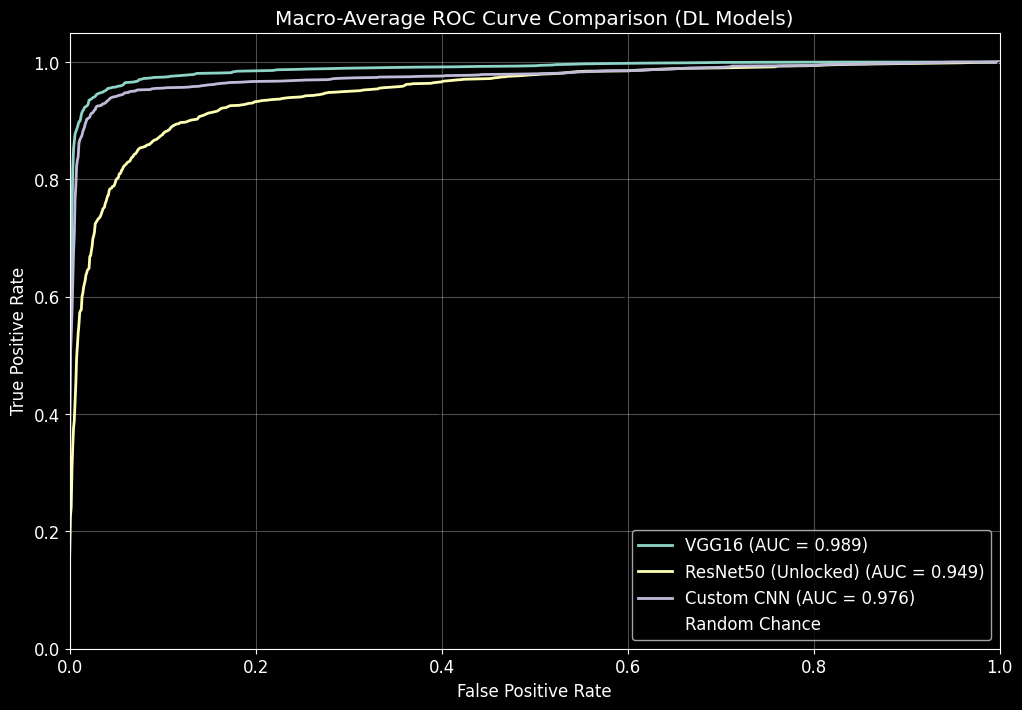

In [93]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparation
# Define the models to evaluate and their respective saved file paths
dl_model_info = {
    "VGG16": "best_vgg16_model.keras",

    "ResNet50 (Unlocked)": "resnet50_fully_unlocked.keras",
    "Custom CNN": "best_custom_cnn.keras"
}

# Binarize labels for multi-class ROC (4 classes)
n_classes = len(unique_labels)
y_test_numeric = encode_label(test_labels)
y_test_bin = label_binarize(y_test_numeric, classes=[0, 1, 2, 3])

plt.figure(figsize=(12, 8))

# 2. Loop through each DL model to get predictions and plot ROC
for name, model_path in dl_model_info.items():
    try:
        # Load the saved model
        current_model = tf.keras.models.load_model(model_path)

        # Setup test generator
        batch_size = 32
        test_steps = len(test_paths) // batch_size
        test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)

        # Get prediction probabilities
        print(f"Calculating ROC for {name}...")
        y_score = current_model.predict(test_gen, steps=test_steps, verbose=0)

        # Match true labels to the actual number of predictions made
        y_true_bin_subset = y_test_bin[:len(y_score)]

        # Compute ROC curve and ROC area (Macro-average)
        fpr = dict()
        tpr = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin_subset[:, i], y_score[:, i])

        # Aggregate all false positive rates
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

        # Interpolate all ROC curves at these points
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes

        # Calculate Macro AUC
        macro_auc = auc(all_fpr, mean_tpr)

        # Plot the curve
        plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:.3f})', lw=2)

    except Exception as e:
        print(f"Could not process {name}: {e}")

# 3. Final Plot Formatting
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison (DL Models)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

This code block generates and plots the Macro-Average ROC curves for the VGG16, fully unlocked ResNet50, and Custom CNN models. It calculates the AUC for each and presents them on a single graph to compare their overall discriminative power.

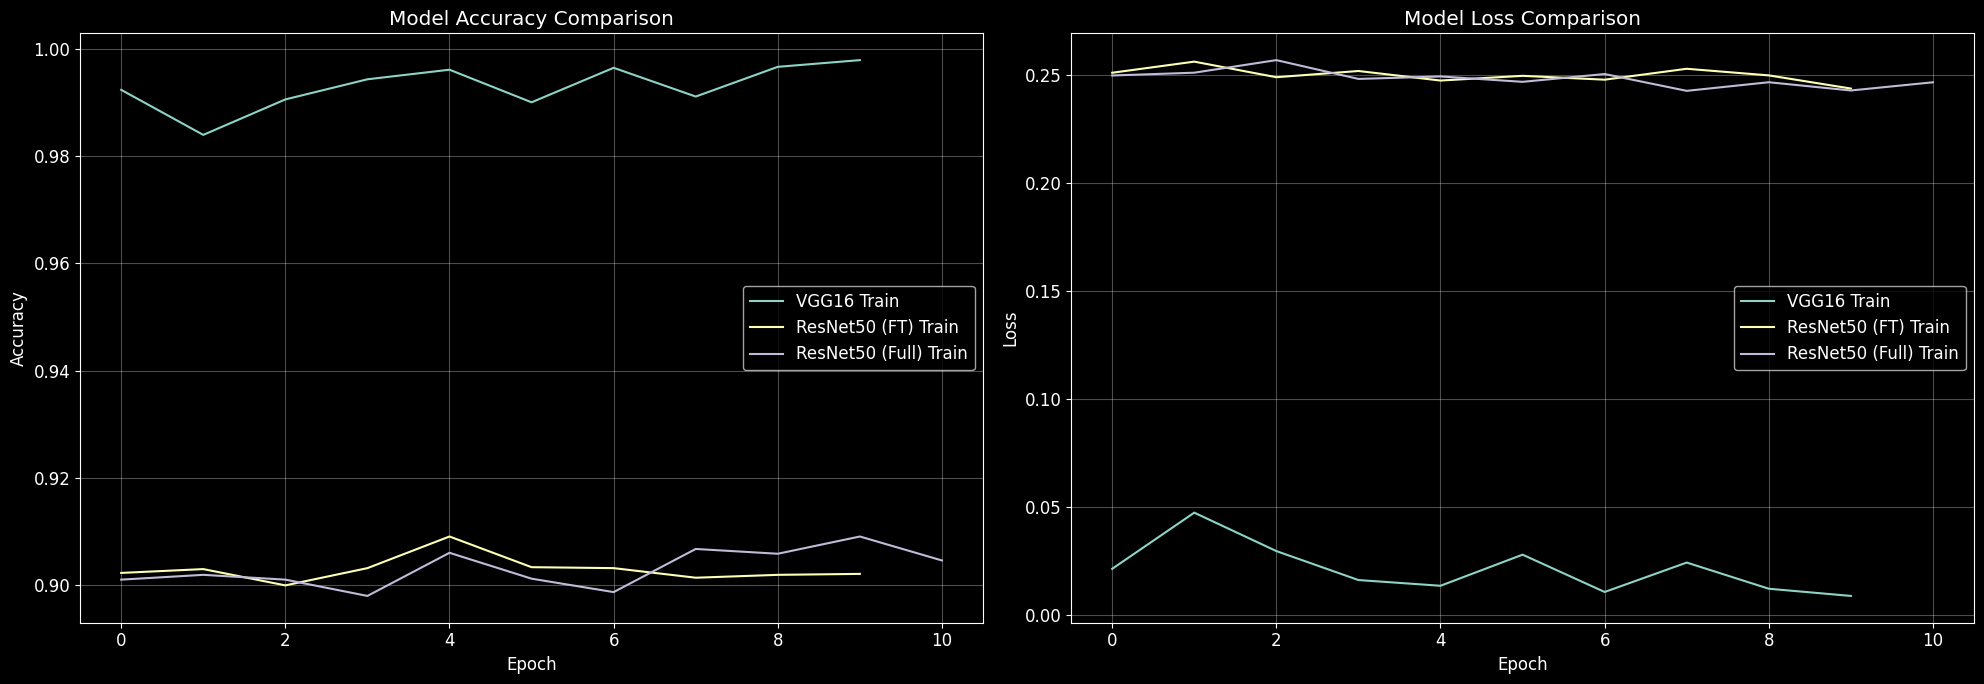

In [94]:
import matplotlib.pyplot as plt

# Define the histories you've collected in your notebook
model_histories = {
    "VGG16": history,           # From Cell [29]
    "ResNet50 (FT)": resnet_ft_history, # From Cell [37]
    "ResNet50 (Full)": final_history # From Cell [40]
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# 1. Accuracy Plot
for name, hist in model_histories.items():
    axes[0].plot(hist.history['sparse_categorical_accuracy'], label=f'{name} Train')
    # If you had a validation_data split in your .fit()
    if 'val_sparse_categorical_accuracy' in hist.history:
        axes[0].plot(hist.history['val_sparse_categorical_accuracy'], linestyle='--', label=f'{name} Val')

axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Loss Plot
for name, hist in model_histories.items():
    axes[1].plot(hist.history['loss'], label=f'{name} Train')
    if 'val_loss' in hist.history:
        axes[1].plot(hist.history['val_loss'], linestyle='--', label=f'{name} Val')

axes[1].set_title('Model Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

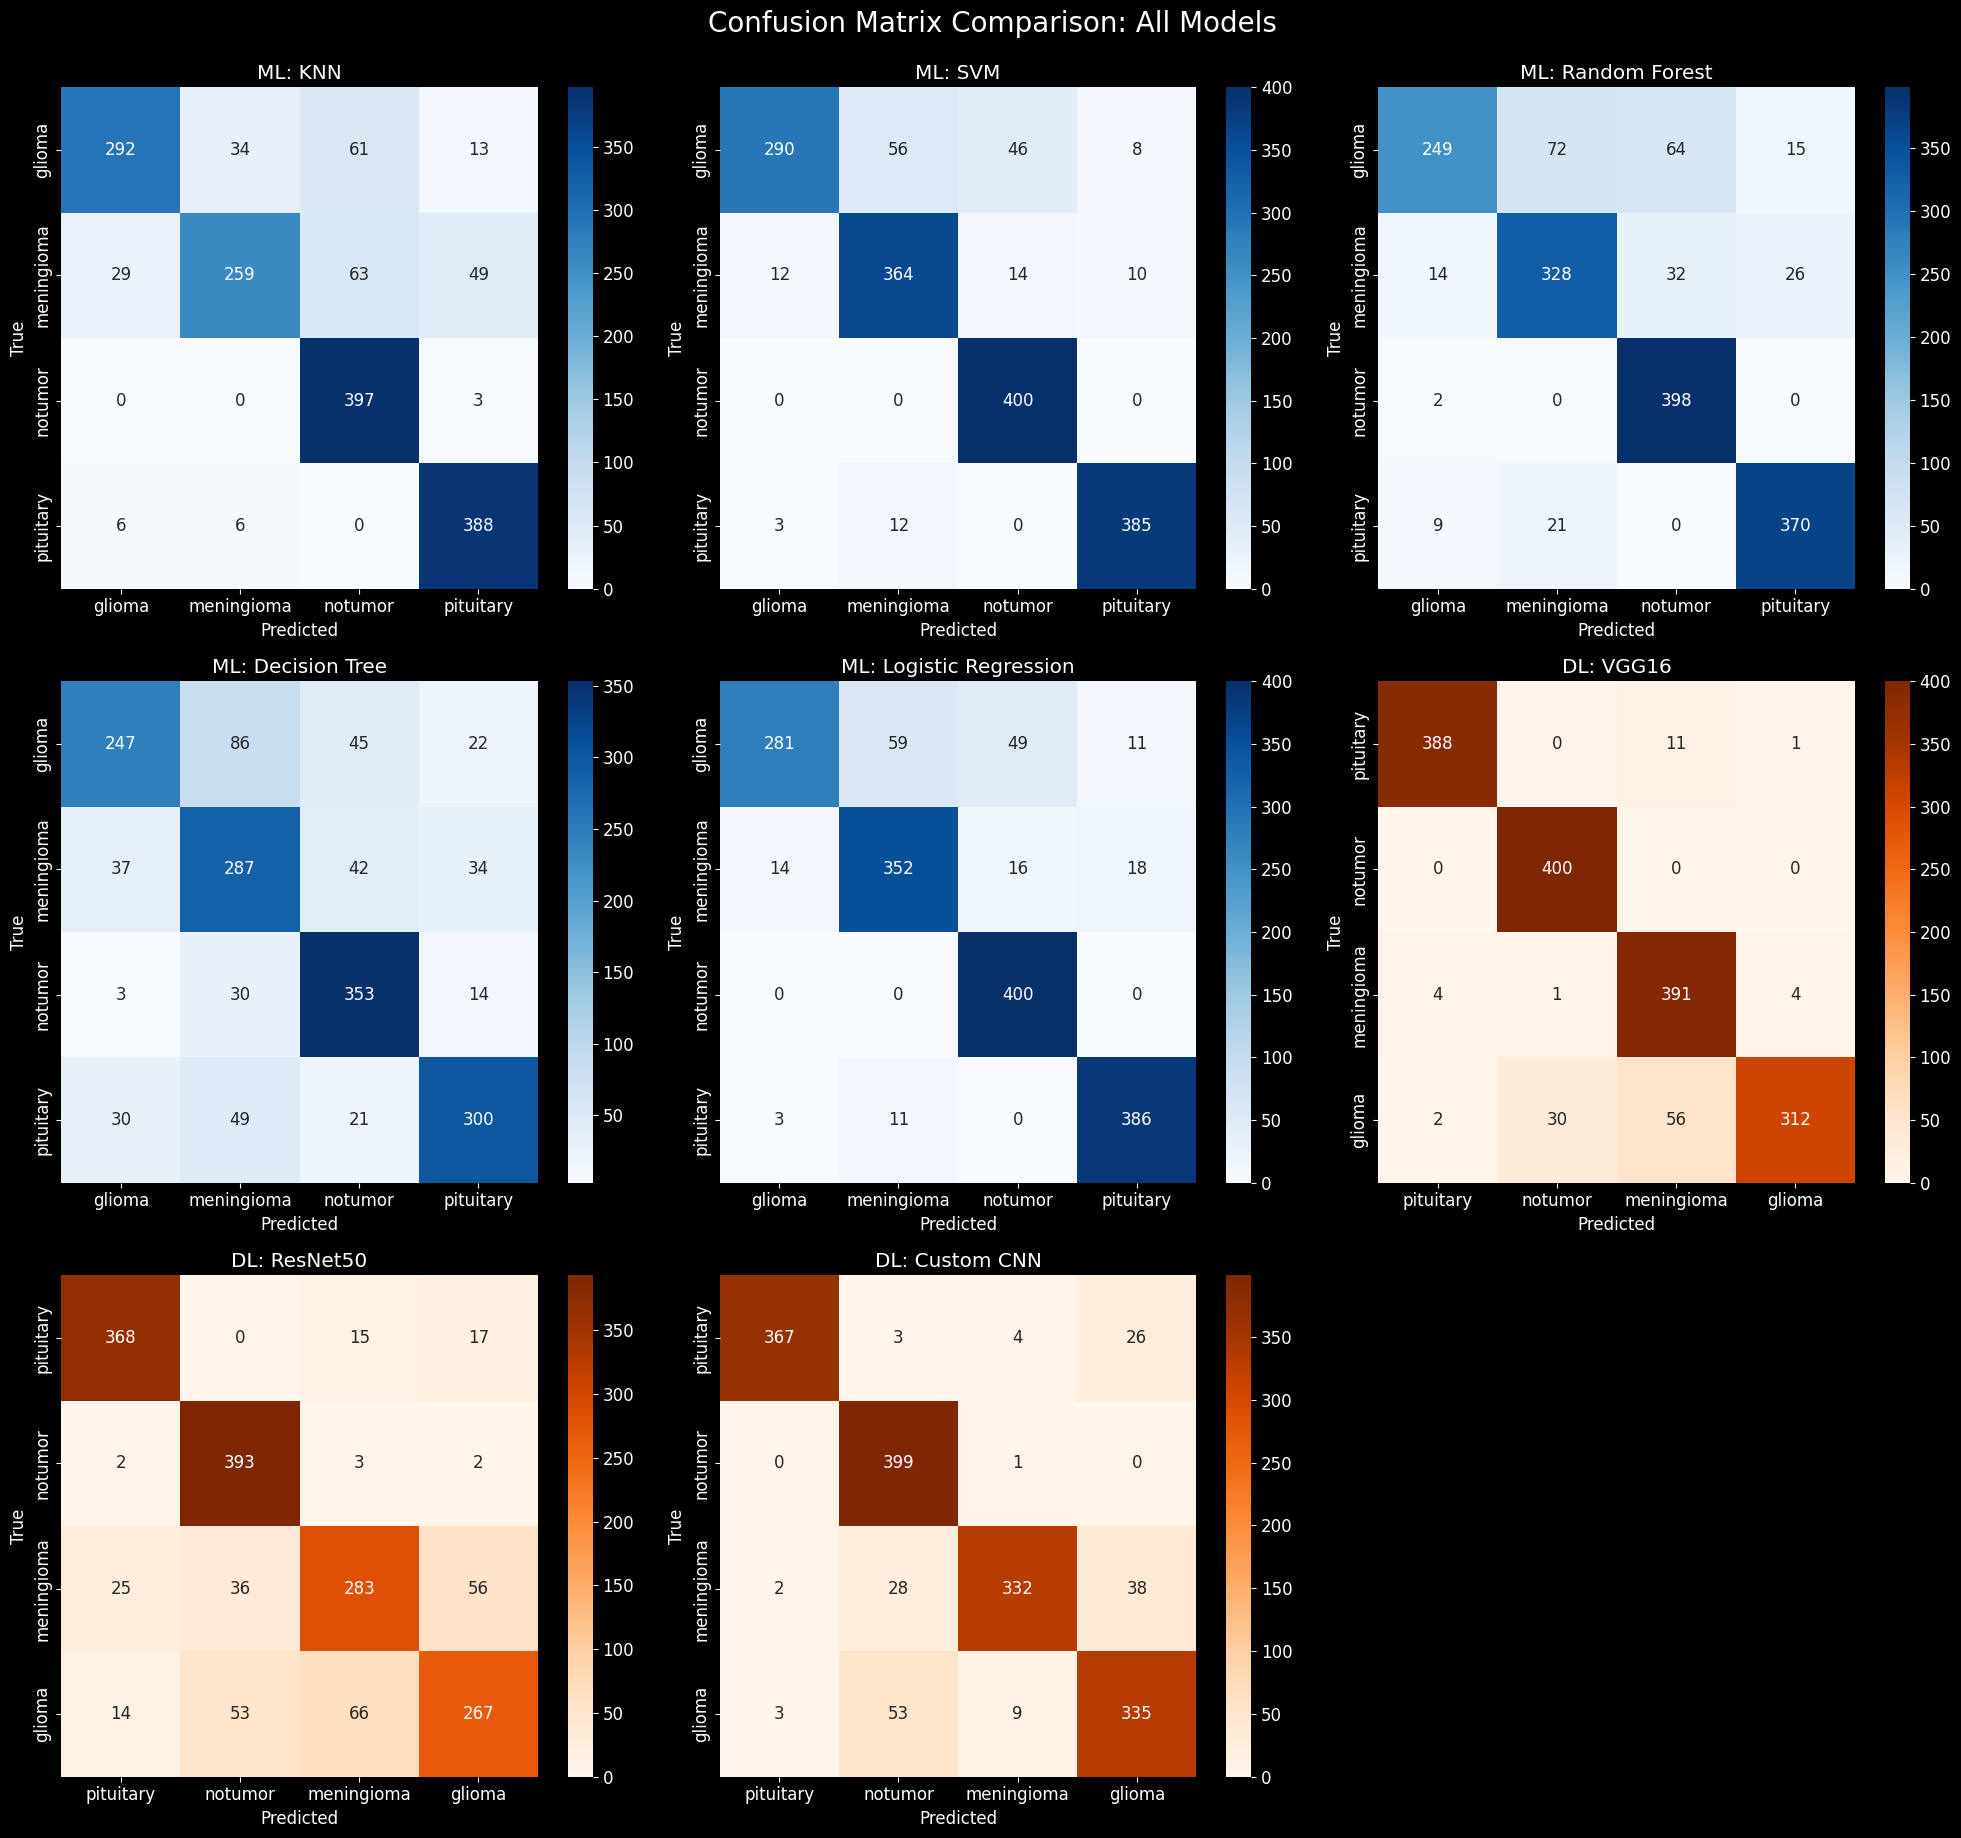

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Define the grid size (Total models: 5 ML + 3 DL = 8)
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

# --- PART A: ML MODELS (HOG Features) ---
for i, (name, model) in enumerate(models.items()):
    y_pred_ml = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_ml)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f"ML: {name}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

# --- PART B: DL MODELS (Image Data) ---
# Define DL models and their labels
dl_models = {
    "VGG16": best_model,
    "ResNet50": ft_model,
    "Custom CNN": custom_model
}

# Use your existing datagen for DL predictions
batch_size = 32
test_steps = len(test_paths) // batch_size

for j, (name, model) in enumerate(dl_models.items()):
    # Reset/Create test generator for each model
    test_gen = datagen(test_paths, test_labels, batch_size=batch_size, epochs=1)
    y_pred_probs = model.predict(test_gen, steps=test_steps, verbose=0)
    y_pred_dl = np.argmax(y_pred_probs, axis=1)
    y_true_dl = encode_label(test_labels[:len(y_pred_dl)])
    
    cm_dl = confusion_matrix(y_true_dl, y_pred_dl)
    
    idx = len(models) + j # Position after ML models
    sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Oranges', ax=axes[idx],
                xticklabels=unique_labels, yticklabels=unique_labels)
    axes[idx].set_title(f"DL: {name}")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

# Clean up empty subplots
for k in range(len(models) + len(dl_models), len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.suptitle("Confusion Matrix Comparison: All Models", fontsize=20, y=1.02)
plt.show()

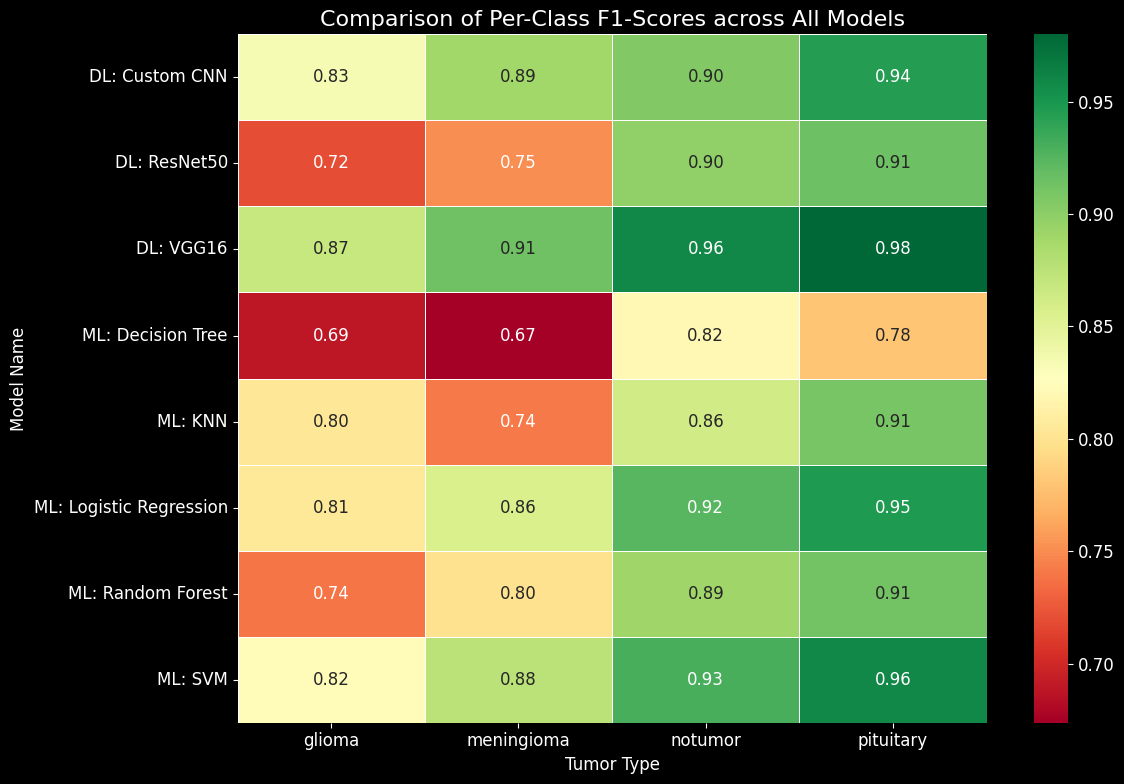

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

# 1. Collect metrics into a list
all_data = []

# --- Collect ML Metrics ---
for name, model in models.items():
    y_pred_ml = model.predict(X_test)
    report = classification_report(y_test, y_pred_ml, target_names=le.classes_, output_dict=True)
    for class_name in le.classes_:
        all_data.append({
            'Model': f"ML: {name}",
            'Class': class_name,
            'F1-Score': report[class_name]['f1-score']
        })

# --- Collect DL Metrics ---
dl_models_dict = {"VGG16": best_model, "ResNet50": ft_model, "Custom CNN": custom_model}
test_steps = len(test_paths) // 32

for name, model in dl_models_dict.items():
    test_gen = datagen(test_paths, test_labels, batch_size=32, epochs=1)
    y_pred_probs = model.predict(test_gen, steps=test_steps, verbose=0)
    y_pred_dl = np.argmax(y_pred_probs, axis=1)
    y_true_dl = encode_label(test_labels[:len(y_pred_dl)])
    
    report = classification_report(y_true_dl, y_pred_dl, target_names=unique_labels, output_dict=True)
    for class_name in unique_labels:
        all_data.append({
            'Model': f"DL: {name}",
            'Class': class_name,
            'F1-Score': report[class_name]['f1-score']
        })

# 2. Convert to DataFrame and Pivot for Heatmap
df_metrics = pd.DataFrame(all_data)
heatmap_data = df_metrics.pivot(index='Model', columns='Class', values='F1-Score')

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Comparison of Per-Class F1-Scores across All Models', fontsize=16)
plt.ylabel('Model Name')
plt.xlabel('Tumor Type')
plt.tight_layout()
plt.show()

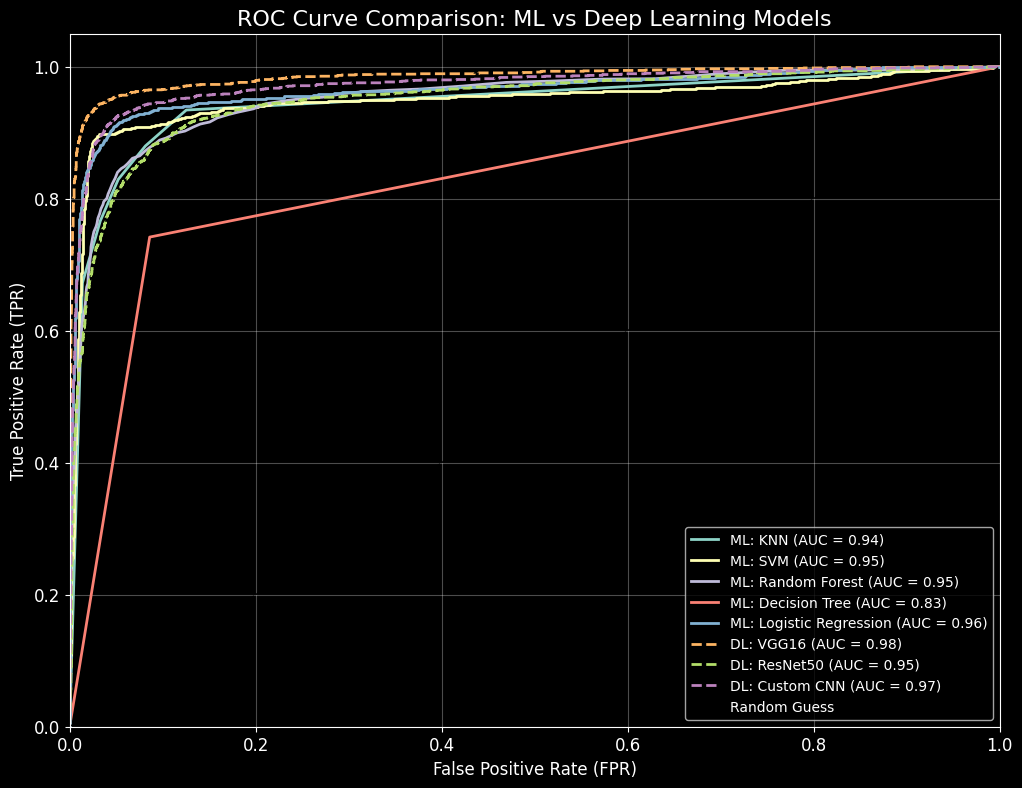

In [97]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Binarize labels for multi-class ROC (Macro-average)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = 4
plt.figure(figsize=(12, 9))

# --- PART A: ML MODELS ---
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    # Calculate Macro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ML: {name} (AUC = {roc_auc:.2f})', lw=2)

# --- PART B: DL MODELS ---
dl_dict = {
    "VGG16": best_model,
    "ResNet50": ft_model,
    "Custom CNN": custom_model
}

for name, model in dl_dict.items():
    # Re-run generator to get fresh predictions
    test_gen = datagen(test_paths, test_labels, batch_size=32, epochs=1)
    y_score_dl = model.predict(test_gen, steps=len(test_paths)//32, verbose=0)
    
    # Align true labels with DL predictions (in case of batch truncation)
    y_true_dl_bin = label_binarize(encode_label(test_labels[:len(y_score_dl)]), classes=[0,1,2,3])
    
    fpr, tpr, _ = roc_curve(y_true_dl_bin.ravel(), y_score_dl.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'DL: {name} (AUC = {roc_auc:.2f})', linestyle='--', lw=2)

# 2. Plot Styling
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison: ML vs Deep Learning Models', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()